In [1]:
#pip install tensorflow pandas numpy matplotlib scikit-learn


In [62]:
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.stattools import acf, q_stat
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [102]:

# Load the dataset
file_path = 'acm_ts.csv'  # Replace with your file path
data = pd.read_csv(file_path)

# Preprocessing the data
# Convert the 'Reporting Period' column to datetime and sort
data['Reporting Period'] = pd.to_datetime(data['Reporting Period'], format='%Y %b')
data = data.sort_values(by='Reporting Period')

# Use only the 'Value' column for forecasting
values = data['Value'].values.reshape(-1, 1)

# Normalize the values
scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)

# Define a function to create sequences for LSTM
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# Create train-test split (80-20), ensuring no missing rows
time_steps = 12
train_size = int(len(values_scaled) * 0.8)

# Include the last `time_steps` rows of training in test
train = values_scaled[:train_size]
test = values_scaled[train_size - time_steps:]

# Create sequences
X_train, y_train = create_sequences(train, time_steps)
X_test, y_test = create_sequences(test, time_steps)

# Print the shapes to confirm correctness
print(f"Dataset size: {len(values_scaled)}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Dataset size: 130
X_train shape: (92, 12, 1), y_train shape: (92, 1)
X_test shape: (26, 12, 1), y_test shape: (26, 1)


In [105]:

# Test RMSE: 5.39, Test MAPE: 13.39%

from tensorflow.keras.layers import Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps, 1)),# need to change the number if add more exo variables
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])


model.compile(optimizer='adam', loss='mean_squared_error')

In [106]:

# Train the model
model.fit(X_train, y_train, batch_size=1, epochs=50, verbose=0)

# Predict values
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scale the predictions and actual values
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train)
y_test_inv = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [72]:
# print(f"Shape of test_index: {len(test_index)}")
# print(f"Shape of test_predict: {test_predict.shape[0]}")


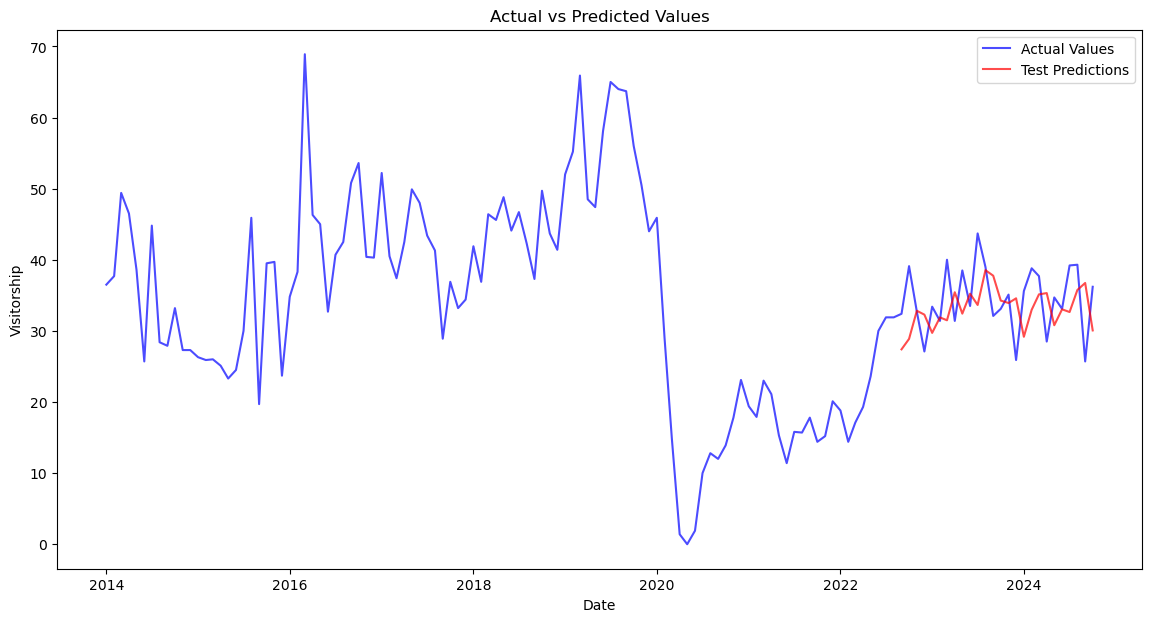

<Figure size 640x480 with 0 Axes>

In [117]:
# Adjust the train and test indices for plotting
train_index = data['Reporting Period'][time_steps:train_size]
test_index = data['Reporting Period'][train_size:train_size + len(test_predict)]

# Visualize actual vs predicted values
plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(data['Reporting Period'], values, label='Actual Values', color='blue', alpha=0.7)

# Plot train predictions
#plt.plot(train_index, train_predict.flatten(), label='Train Predictions', color='green', alpha=0.7)

# Plot test predictions
plt.plot(test_index, test_predict.flatten(), label='Test Predictions', color='red', alpha=0.7)

plt.xlabel('Date')
plt.ylabel('Visitorship')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches='tight')  # Save as PNG
# plt.savefig("actual_vs_predicted.jpg", dpi=300)  # Save as JPG
# plt.savefig("actual_vs_predicted.pdf", bbox_inches='tight')  # Save as PDF

In [108]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Compute RMSE and MAPE
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
train_mape = mean_absolute_percentage_error(y_train_inv, train_predict) * 100
test_mape = mean_absolute_percentage_error(y_test_inv, test_predict) * 100

print(f"Train RMSE: {train_rmse:.2f}, Train MAPE: {train_mape:.2f}%")
print(f"Test RMSE: {test_rmse:.2f}, Test MAPE: {test_mape:.2f}%")


Train RMSE: 7.52, Train MAPE: 3089798305631744.00%
Test RMSE: 5.78, Test MAPE: 14.30%


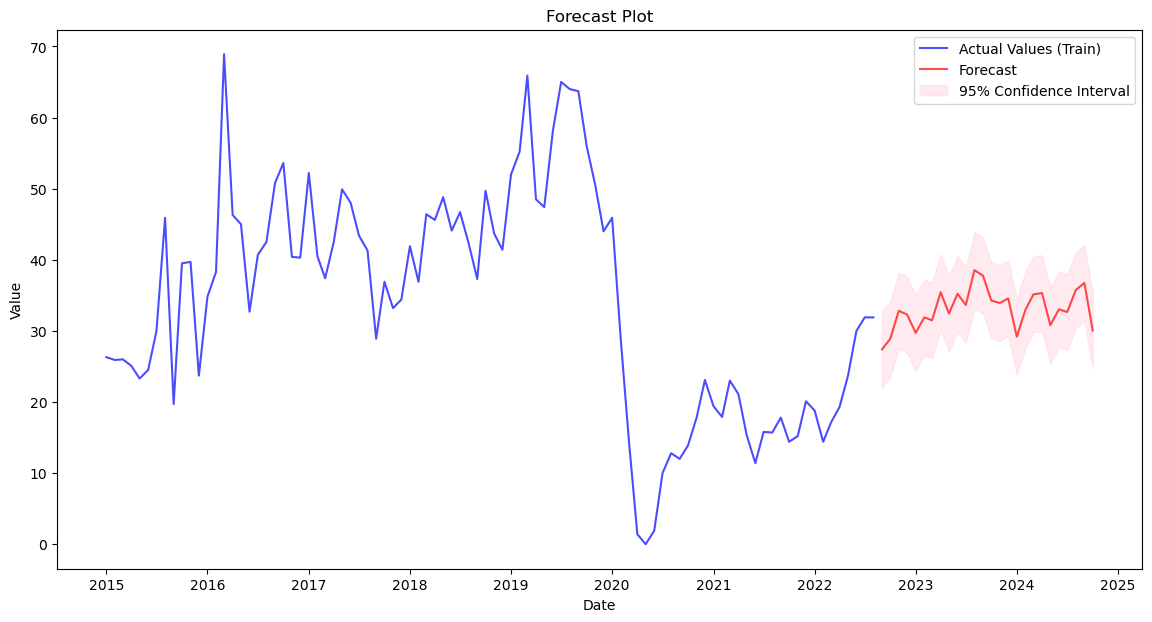

<Figure size 640x480 with 0 Axes>

In [118]:
# Indices for training data
train_index = data['Reporting Period'][time_steps:train_size]

# Indices for forecasted data
forecast_index = data['Reporting Period'][train_size:train_size + len(test_predict)]

# Lower and upper bounds for confidence intervals
lower_bound = test_predict.flatten() - 1.96 * np.std(test_predict)
upper_bound = test_predict.flatten() + 1.96 * np.std(test_predict)

# Plot
plt.figure(figsize=(14, 7))

# Plot actual values for training data only
plt.plot(train_index, scaler.inverse_transform(values_scaled[:train_size][time_steps:]), label='Actual Values (Train)', color='blue', alpha=0.7)

# Plot forecast (test predictions)
plt.plot(forecast_index, test_predict.flatten(), label='Forecast', color='red', alpha=0.7)

# Optionally, add confidence intervals
plt.fill_between(forecast_index, lower_bound, upper_bound, color='pink', alpha=0.3, label='95% Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Forecast Plot')
plt.legend()
plt.show()
plt.savefig("forecast_plot.png", dpi=300, bbox_inches='tight')  # Save as PNG


In [110]:
# Compute residuals on the test set
residuals = y_test_inv - test_predict

# Optionally, flatten the array if needed (for 1D operations):
residuals = residuals.flatten()


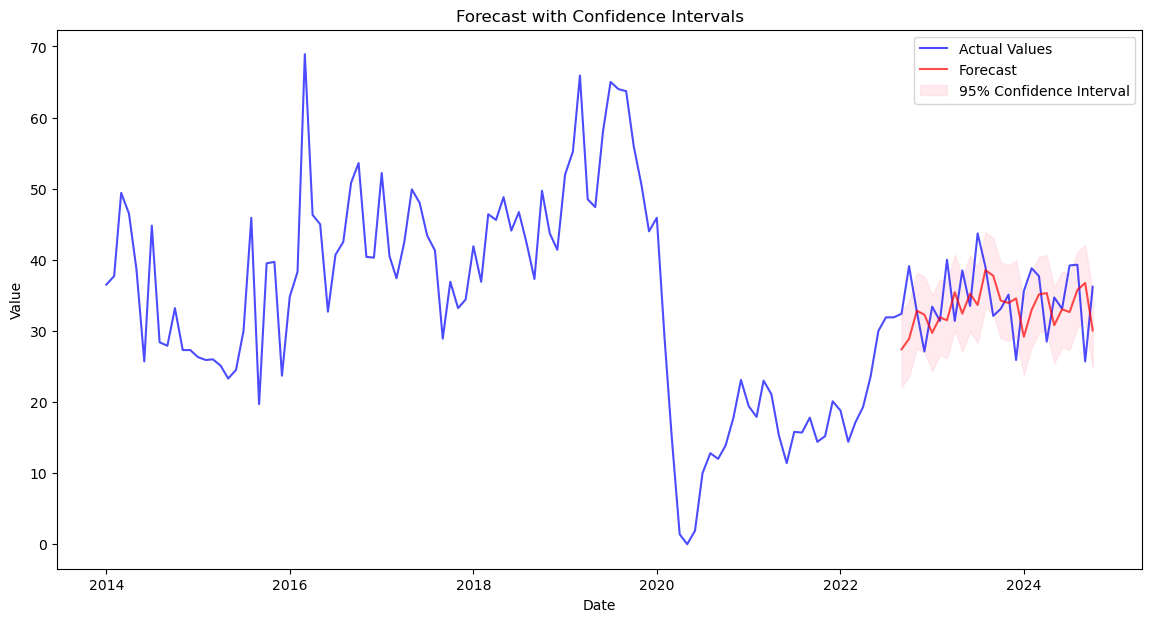

<Figure size 640x480 with 0 Axes>

In [119]:
# Forecast plot with confidence intervals
#forecast_index = data['Reporting Period'][train_size + time_steps:]
lower_bound = test_predict.flatten() - 1.96 * np.std(test_predict)
upper_bound = test_predict.flatten() + 1.96 * np.std(test_predict)

plt.figure(figsize=(14, 7))
plt.plot(data['Reporting Period'], values, label='Actual Values', color='blue', alpha=0.7)
plt.plot(forecast_index, test_predict.flatten(), label='Forecast', color='red', alpha=0.7)
plt.fill_between(forecast_index, lower_bound, upper_bound, color='pink', alpha=0.3, label='95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Forecast with Confidence Intervals')
plt.legend()
plt.show()
plt.savefig("forecastwithconfidenceintervals.png", dpi=300, bbox_inches='tight')  # Save as PNG


In [112]:
from statsmodels.tsa.stattools import acf, q_stat

# Assume 'residuals' is already defined (e.g., from your model's residuals)
# Compute the autocorrelation function values for your residuals
acf_values = acf(residuals, fft=False)

# Box-Ljung Test
q_stat_val, p_val = q_stat(acf_values[1:], len(residuals))
print("Box-Ljung Test:")
print(f"Q-statistic: {q_stat_val[-1]:.2f}, p-value: {p_val[-1]:.4f}")

if p_val[-1] < 0.05:
    print("The residuals are not random (significant autocorrelation exists).")
else:
    print("The residuals appear random (no significant autocorrelation).")

Box-Ljung Test:
Q-statistic: 13.36, p-value: 0.4981
The residuals appear random (no significant autocorrelation).


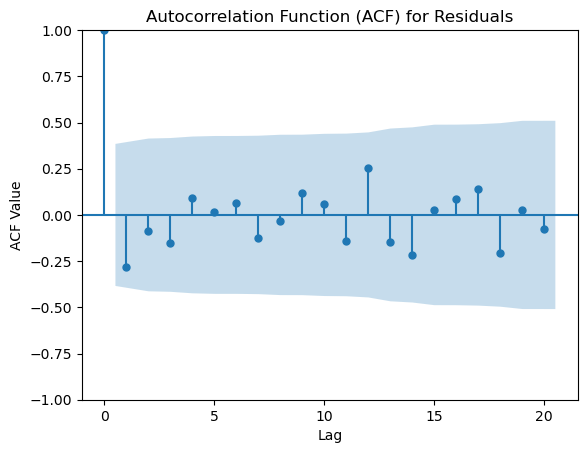

<Figure size 640x480 with 0 Axes>

In [120]:
from statsmodels.graphics.tsaplots import plot_acf

# Adjust the max_lags to be at most the length of residuals
max_lags = min(20, len(residuals) - 1)

# ACF plot for residuals
acf_plot = plot_acf(residuals, lags=max_lags)
plt.title('Autocorrelation Function (ACF) for Residuals')
plt.xlabel('Lag')
plt.ylabel('ACF Value')
plt.show()
plt.savefig("acfplot.png", dpi=300, bbox_inches='tight')  # Save as PNG



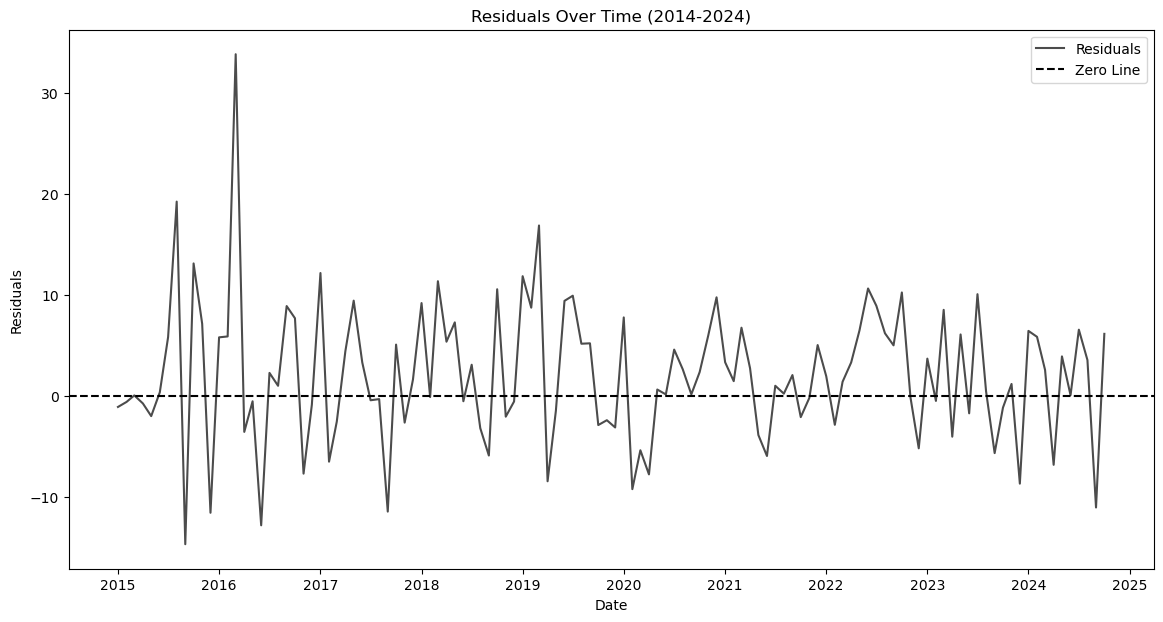

<Figure size 640x480 with 0 Axes>

In [121]:

# Compute residuals for the training set
train_residuals = y_train_inv - train_predict

# Compute residuals for the test set
test_residuals = y_test_inv - test_predict

# Flatten them in case they are 2D arrays
train_residuals = train_residuals.flatten()
test_residuals = test_residuals.flatten()



# Align residuals with the corresponding timeline
residuals_full = np.concatenate([train_residuals, test_residuals])
residuals_timeline = data['Reporting Period'][time_steps:time_steps + len(residuals_full)]

# Line plot of residuals
plt.figure(figsize=(14, 7))
plt.plot(residuals_timeline, residuals_full, label='Residuals', color='black', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', label='Zero Line')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('Residuals Over Time (2014-2024)')
plt.legend()
plt.show()
plt.savefig("residualsovertime.png", dpi=300, bbox_inches='tight')  # Save as PNG

# higher variance at the start, lower towards the end?

In [ ]:
#Test RMSE: 34.28, Test MAPE: 98.53%
# got worse results with exogenous variable

In [122]:
model.save("lstm_model.h5")
print("Model saved successfully as lstm_model.h5")


Model saved successfully as lstm_model.h5


In [123]:
import pickle

# Convert the model to a dictionary
model_dict = {
    "model_config": model.to_json(),  # Save architecture
    "model_weights": model.get_weights()  # Save weights separately
}

# Save using pickle
with open("lstm_model.pkl", "wb") as f:
    pickle.dump(model_dict, f)

print("Model saved successfully as lstm_model.pkl")


Model saved successfully as lstm_model.pkl


In [124]:
from tensorflow.keras.models import model_from_json

# Load the dictionary
with open("lstm_model.pkl", "rb") as f:
    loaded_dict = pickle.load(f)

# Reconstruct the model
loaded_model = model_from_json(loaded_dict["model_config"])
loaded_model.set_weights(loaded_dict["model_weights"])

print("Model loaded successfully from pickle!")



Model loaded successfully from pickle!
